# This notebook attempts to visualize multisite 

In [27]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import extracellular as ex
import helperFuncs as hf

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [28]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Simulate just a single, simplified axon fiber 

In [29]:
h.load_file('stdrun.hoc')
h.load_file('interpxyz.hoc')
h.load_file('setpointers.hoc')

# Axon parameters 
L = 1000 # length[um]
d = 2 # diamter [um]
dx = 2 # segment length [um]

# Setup axon geometry
axon = h.Section(name='axon')
h.pt3dadd(-L/2, 0, 0, d, sec=axon)
h.pt3dadd(L/2, 0, 0, d, sec=axon)
axon.nseg = int(L/dx)

# Setup axon biophysics 
axon.insert('pas')
axon.insert('mammalian_spike_35')
axon.insert('cad')
axon.insert('extracellular')
axon.insert('xtra')

axon.Ra = 143.2 # [Ohm*cm]
axon.cm = 1.0 # [uF/cm^2]
axon.ena = 60.6 # [mV]
axon.ek = -101.34 # [mV]
axon.e_pas = -70 # [mV]

# SOCB
axon.gnabar_mammalian_spike_35 = 0.42 # [S/cm^2]
axon.gkbar_mammalian_spike_35 = 0.050 # [S/cm^2]
axon.gkcbar_mammalian_spike_35 = 0.00031 # [S/cm^2]
axon.gcabar_mammalian_spike_35 = 0.0 # [S/cm^2]
axon.g_pas = 0.0002 # [S/cm^2]

# Distal Axon
# axon.gnabar_mammalian_spike_35 = 0.08 # [S/cm^2]
# axon.gkbar_mammalian_spike_35 = 0.050 # [S/cm^2]
# axon.gkcbar_mammalian_spike_35 = 0.0002 # [S/cm^2]
# axon.gcabar_mammalian_spike_35 = 0.00075 # [S/cm^2]
# axon.g_pas = 0.0001 # [S/cm^2]

h.setpointers()

0.0

### define segment centers for xtra mechanism 

In [30]:
# Compute segment centers and allocate memory 
n3d = int(h.n3d(sec=axon))
xx = h.Vector(n3d)
yy = h.Vector(n3d)
zz = h.Vector(n3d)
dd = h.Vector(n3d)
ll = h.Vector(n3d)

# Get xyz coordinates, diameters, and lengths along each segment 
for i in range(n3d):
    xx.x[i] = h.x3d(i, sec=axon)
    yy.x[i] = h.y3d(i, sec=axon)
    zz.x[i] = h.z3d(i, sec=axon)
    dd.x[i] = h.diam3d(i, sec=axon)
    ll.x[i] = h.arc3d(i, sec=axon)

# Interpolate the xyz coordinates to the center of each segment
ll.div(axon.L)
rint = h.Vector(axon.nseg+2)
rint.indgen(1./axon.nseg)
rint.sub(1./(2.*axon.nseg))
rint.x[0] = 0
rint.x[axon.nseg+1] = 1

xint = h.Vector(axon.nseg+2)
yint = h.Vector(axon.nseg+2)
zint = h.Vector(axon.nseg+2)
dint = h.Vector(axon.nseg+2)
xint.interpolate(rint,ll,xx)
yint.interpolate(rint,ll,yy)
zint.interpolate(rint,ll,zz)
dint.interpolate(rint,ll,dd)

# Set centers in xtra mechanism
for i in range(1,axon.nseg+1):
    axon(rint.x[i]).x_xtra = xint.x[i]
    axon(rint.x[i]).y_xtra = yint.x[i]
    axon(rint.x[i]).z_xtra = zint.x[i]


In [31]:
# Code to traverse through all sections and segments of a cell. This is very
#  useful for debugging and probing different features (membrane voltage, 
#  currents, channel dynamics) at each segment. It also helps to understand 
#  how the cell is layed out in space. 
for sec in h.allsec(): 
    for ii,seg in enumerate(sec):
        print(ii,seg)
        print('Segment coordinates: ', seg.x_xtra, seg.y_xtra, seg.z_xtra)

0 axon(0.001)
Segment coordinates:  -499.0 0.0 0.0
1 axon(0.003)
Segment coordinates:  -497.0 0.0 0.0
2 axon(0.005)
Segment coordinates:  -495.0 0.0 0.0
3 axon(0.007)
Segment coordinates:  -493.0 0.0 0.0
4 axon(0.009)
Segment coordinates:  -491.0 0.0 0.0
5 axon(0.011)
Segment coordinates:  -489.0 0.0 0.0
6 axon(0.013)
Segment coordinates:  -487.0 0.0 0.0
7 axon(0.015)
Segment coordinates:  -485.0 0.0 0.0
8 axon(0.017)
Segment coordinates:  -483.0 0.0 0.0
9 axon(0.019)
Segment coordinates:  -481.0 0.0 0.0
10 axon(0.021)
Segment coordinates:  -479.0 0.0 0.0
11 axon(0.023)
Segment coordinates:  -477.0 0.0 0.0
12 axon(0.025)
Segment coordinates:  -475.0 0.0 0.0
13 axon(0.027)
Segment coordinates:  -473.0 0.0 0.0
14 axon(0.029)
Segment coordinates:  -471.0 0.0 0.0
15 axon(0.031)
Segment coordinates:  -469.0 0.0 0.0
16 axon(0.033)
Segment coordinates:  -467.0 0.0 0.0
17 axon(0.035)
Segment coordinates:  -465.0 0.0 0.0
18 axon(0.037)
Segment coordinates:  -463.0 0.0 0.0
19 axon(0.039)
Segment

## Step 2: Setup electrical stimulus 

In [7]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.1 # units: [ms]
Stim['stop'] = 50 # units: [ms]
Stim['amp'] = [-0.5,0] # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[15,0,10],[-15,0,10]] # units: [um] 
Stim['electrode_type'] = 'disk' # OLD: 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 10 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

## Step 3: define transfer resistances (define number of active segments)

In [8]:
# First let's decide the number of segments to make active in the simulation
num_seg_active = 500

# Determine index of center segment, given axon.nseg is even
center_seg = int(axon.nseg/2)

# Create list of segment indices to activate given num_seg_active
segs = []
while len(segs) < num_seg_active:
    if len(segs) == 0:
        segs.append(center_seg)
    if len(segs) < num_seg_active:
        segs.append(min(segs)-1)
    if len(segs) < num_seg_active:
        segs.append(max(segs)+1)

# Order segs list
segs = sorted(segs)
print(segs)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [9]:
# Set up transfer resistances, only for active segments
elecType = 'disk'
rhoExt = 1000 # [Ohm*cm]
dDisk = 15 # [um]

for idx,seg in enumerate(axon):
    rx = 0
    for i in range(len(Stim['electrodes'])):
        # Current amplitude on elec scaling factor 
        I = Stim['amp'][i]

        if Stim['electrode_type'] == 'disk':
            # Distance from electrode to center of each segment [cm]
            r = 1e-4*\
                np.sqrt((seg.xtra.x - (Stim['electrodes'][i][0]))**2\
                        + (seg.xtra.y - (Stim['electrodes'][i][1]))**2)
            # Vertical distance [cm]
            z = 1e-4*(seg.xtra.z-Stim['electrodes'][i][2])

            # Transfer impedance [MOhm]  
            rDisk = 1e-4*Stim['elecDiam']/2             
            rx += I * (1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
                * np.arcsin((2*rDisk) / \
                (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2))))
        elif Stim['electrode_type'] == 'point':
            dist = 1e-4*\
                np.sqrt((seg.xtra.x - (Stim['electrodes'][i][0]))**2 + \
                        (seg.xtra.y - (Stim['electrodes'][i][1]))**2 + \
                        (seg.xtra.z - (Stim['electrodes'][i][2]))**2)
            rx += I * (1e-6*Stim['rhoExt']/(4.0*np.pi*dist))

    # Set transfer impedance for each segment
    if idx in segs:
        seg.xtra.rx  = rx  # in MOhm
    else:
        seg.xtra.rx  = 0
                        
    # Map references of extracellular and membrane current with 
    #  xtra mechanism
    h.setpointer(seg._ref_e_extracellular,'ex',seg.xtra)
    h.setpointer(seg._ref_i_membrane,'im',seg.xtra)

In [10]:
for seg in axon:
    print(seg.x, seg.xtra.rx)

0.001 -0.0015479312928649935
0.003 -0.0015539757895169457
0.005 -0.0015600676690218898
0.007 -0.001566207490624473
0.009 -0.0015723958224032968
0.011 -0.001578633241446009
0.013 -0.0015849203340285694
0.015 -0.001591257695798818
0.017 -0.0015976459319644554
0.019 -0.0016040856574855737
0.021 -0.0016105774972718465
0.023 -0.0016171220863845325
0.025 -0.001623720070243415
0.027 -0.0016303721048388233
0.029 -0.001637078856948882
0.031 -0.001643841004362142
0.033 -0.0016506592361057418
0.035 -0.0016575342526792703
0.037 -0.0016644667662944889
0.039 -0.0016714575011210898
0.041 -0.0016785071935386665
0.043 -0.0016856165923950835
0.045 -0.001692786459271428
0.047 -0.0017000175687537538
0.049 -0.0017073107087118029
0.051 -0.001714666680584932
0.053 -0.0017220862996754525
0.055 -0.00172957039544961
0.057 -0.0017371198118464398
0.059 -0.0017447354075947347
0.061 -0.0017524180565383848
0.063 -0.0017601686479703305
0.065 -0.0017679880869754163
0.067 -0.0017758772947824126
0.069 -0.001783837209125

## Step 4: Set up recording vectors in order to probe what happened 

### Current recording vectors at all segment compartments

In [11]:
# Setup dictionary to capture iOut at all cell compartments
iOut = {}
iOut['axon'] = {}
h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
for i,seg in enumerate(axon):
    iOut['axon']['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Voltage recording vectors at all segment compartments 

In [12]:
# Capture membrane voltage at all cell compartments
vRec = []
for i in range(axon.nseg):
        vRec.append(h.Vector().record(axon(1/axon.nseg+i/axon.nseg)._ref_v))

### Time vector

In [13]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

## Step 4: Apply stimulus to the cell! 

In [14]:
# Play the stimulus into the cell, setting it up for stimulation
tsvec, isvec = hf.setupStimulus_unit(Stim)
isvec.play(h._ref_is_xtra, tsvec, 1) 

# Initialization phase of the simulation 
h.init()
h.tstop = Stim['initDur']
h.dt = Stim['initDt']
h.finitialize(Stim['vInit'])
h.continuerun(h.tstop)

# Run the simulation 
h.tstop = Stim['initDur'] + Stim['stop']
h.steps_per_ms = int(1/Stim['dt'])
h.dt = Stim['dt']
h.continuerun(h.tstop)
print('***** sim done *****')

***** sim done *****


In [15]:
print(vRec[0][30])

-73.32382465717036


## Step 5: Visualize what happened

### Extracellular recording as observed from a given recording electrode (point source approx)

In [16]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-100,0,7]

# setup vector where to store extracellular voltage profile
timeStepsRec = int(Stim['stop']/Stim['dt'])+1
dtFac = 1
recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for k,seg in enumerate(axon):
    # Compute distance from electrode to center of each segment [um]
    dist = np.sqrt((seg.xtra.x-recElec[0])**2 + (seg.xtra.y-recElec[1])**2 \
                    + (seg.xtra.z-recElec[2])**2)
    
    # Set transfer impedance for each segment [MOhm]
    tf = Stim['rhoExt'] / (4.0*np.pi*dist*(1e-4)) * 1e-6

    # recOut units: 1e3*MOhm*nA == uV
    recOut += 1e3 * tf * \
        (iOut['axon']['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

Text(0, 0.5, 'Extracellular voltage [uV]')

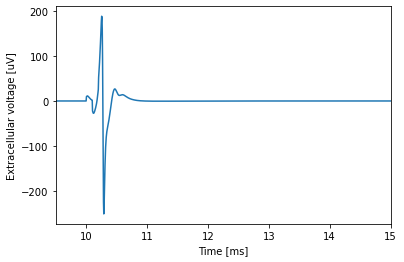

In [17]:
# Plot extracellular voltaged recorded on recElec
plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

### Now try with disk electrode approximations

In [18]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-100,0,7]

# setup vector where to store extracellular voltage profile
timeStepsRec = int(Stim['stop']/Stim['dt'])+1
dtFac = 1
recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for k, seg in enumerate(axon):
    # Distance from electrode to center of each segment [cm]
    r = 1e-4*\
        np.sqrt((seg.xtra.x - (recElec[0]))**2\
                + (seg.xtra.y - (recElec[1]))**2)
    # Vertical distance [cm]
    z = 1e-4*(seg.xtra.z-recElec[2])

    # Transfer impedance [MOhm]  
    rDisk = 1e-4*Stim['elecDiam']/2             
    tf = 1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
        * np.arcsin((2*rDisk) / \
        (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2)))
                
    # recOut units: 1e3*MOhm*nA == uV
    recOut += 1e3 * tf * \
        (iOut['axon']['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

Text(0, 0.5, 'Extracellular voltage [uV]')

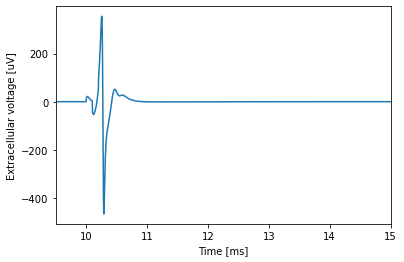

In [19]:
# Plot extracellular voltaged recorded on recElec
plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

### Plot voltage trace to see if there was an AP 

Text(0, 0.5, 'Distance along axon (um)')

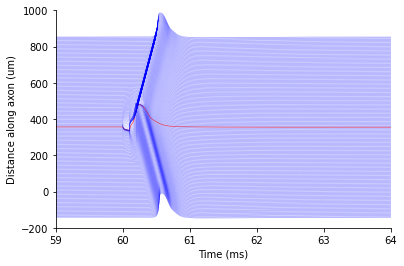

In [20]:
vInit = -70
numSeg = axon.nseg
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
offset = Stim['vInit']
for cnt in range(numSeg):
    if cnt==numSeg/2:
        plt.plot(t,np.array(vRec[cnt])+offset,'r',linewidth=0.5)
    else:
        plt.plot(t,np.array(vRec[cnt])+offset,'b',linewidth=0.1)
    offset += 2
plt.xlim(Stim['initDur']+9,Stim['initDur']+14)
plt.ylim(-200,1000)
plt.xlabel('Time (ms)')
plt.ylabel('Distance along axon (um)')

### Codify threshold finding into a function 

In [26]:
def setStim(electrodes, currents):
    ### Most features of the stimulus are set up a struct (dict) called Stim 
    Stim = {}

    # temporal features of the sitmulus 
    Stim['pulseShape'] = 'monophasic'
    Stim['dt'] = .005 # units: [ms]
    Stim['delay'] = 10 # units: [ms]
    Stim['dur'] = 0.1 # units: [ms]
    Stim['stop'] = 50 # units: [ms]
    Stim['amp'] = currents # units: [uA]

    # calibration phase of the stimulus 
    Stim['initDur'] = 50 # units: [ms]
    Stim['initDt'] = 1 # units: [ms]
    Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

    # spatial features of the stimulus 
    # --> specifically defining the electrode geometry 
    Stim['electrodes'] = electrodes # units: [um] 
    Stim['electrode_type'] = 'disk' # Old: 'disk'
    Stim['rhoExt'] = 1000 # Ohm*cm
    Stim['elecDiam'] = 15 # um
    Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

    Stim['pulseRatioTri'] = [-2/3,1,-1/3]
    Stim['pulseRatioBi'] = [1,-1]
    Stim['frequency'] = 10 # units: [Hz]

    return Stim

In [22]:
def setTransferResistance(Stim,axon):
    # First let's decide the number of segments to make active in the simulation
    num_seg_active = 500

    # Determine index of center segment, given axon.nseg is even
    center_seg = int(axon.nseg/2)

    # Create list of segment indices to activate given num_seg_active
    segs = []
    while len(segs) < num_seg_active:
        if len(segs) == 0:
            segs.append(center_seg)
        if len(segs) < num_seg_active:
            segs.append(min(segs)-1)
        if len(segs) < num_seg_active:
            segs.append(max(segs)+1)

    # Order segs list
    segs = sorted(segs)

    # Set up transfer resistances, only for active segments
    for idx,seg in enumerate(axon):
        rx = 0
        for i in range(len(Stim['electrodes'])):
            # Current amplitude on elec scaling factor 
            I = Stim['amp'][i]

            if Stim['electrode_type'] == 'disk':
                # Distance from electrode to center of each segment [cm]
                r = 1e-4*\
                    np.sqrt((seg.xtra.x - (Stim['electrodes'][i][0]))**2\
                            + (seg.xtra.y - (Stim['electrodes'][i][1]))**2)
                # Vertical distance [cm]
                z = 1e-4*(seg.xtra.z-Stim['electrodes'][i][2])

                # Transfer impedance [MOhm]  
                rDisk = 1e-4*Stim['elecDiam']/2             
                rx += I * (1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
                    * np.arcsin((2*rDisk) / \
                    (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2))))
            elif Stim['electrode_type'] == 'point':
                dist = 1e-4*\
                    np.sqrt((seg.xtra.x - (Stim['electrodes'][i][0]))**2 + \
                            (seg.xtra.y - (Stim['electrodes'][i][1]))**2 + \
                            (seg.xtra.z - (Stim['electrodes'][i][2]))**2)
                rx += I * (1e-6*Stim['rhoExt']/(4.0*np.pi*dist))

        # Set transfer impedance for each segment
        if idx in segs:
            seg.xtra.rx  = rx  # in MOhm
        else:
            seg.xtra.rx  = 0
                            
        # Map references of extracellular and membrane current with 
        #  xtra mechanism
        h.setpointer(seg._ref_e_extracellular,'ex',seg.xtra)
        h.setpointer(seg._ref_i_membrane,'im',seg.xtra)

In [23]:
def find_threshold(electrodes, primary_elec_curr, axon):
    # Start at 0uA 
    current = 0.05
    currents = [primary_elec_curr,-1*current]
    precision = 1 # %
    upperLim = 10

    firstAP = 0
    stop = False
    while not stop:
        Stim = setStim(electrodes, currents)
        setTransferResistance(Stim,axon)
        
        # Setup recording vectors 
        # Capture membrane voltage at all cell compartments
        vRec = []
        for i in range(axon.nseg):
                vRec.append(h.Vector().record(axon(1/axon.nseg+i/axon.nseg)._ref_v))
        t = h.Vector().record(h._ref_t)

        # Play the stimulus into the cell, setting it up for stimulation
        print('Testing: secondary current = ', currents[1], ' uA')
        tsvec, isvec = hf.setupStimulus_unit(Stim)
        isvec.play(h._ref_is_xtra, tsvec, 1) 

        # Initialization phase of the simulation 
        h.init()
        h.tstop = Stim['initDur']
        h.dt = Stim['initDt']
        h.finitialize(Stim['vInit'])
        h.continuerun(h.tstop)

        # Run the simulation 
        h.tstop = Stim['initDur'] + Stim['stop']
        h.steps_per_ms = int(1/Stim['dt'])
        h.dt = Stim['dt']
        h.continuerun(h.tstop)
        
        # Check to see if we see a spike 
        if firstAP == 0:
            if (max(vRec[0]) < 0):
                print('Cell did not spike')
                current = current * 2
            else:
                firstAP = 1
                stepCurr = current / 4
                current = current - stepCurr
        else:
            if (max(vRec[0]) > 0 and stepCurr <= current*precision/100):
                stop = True
                vReturn = np.array(vRec)
            if (max(vRec[0]) > 0 and stepCurr > current*precision/100):
                stepCurr = stepCurr / 2
                current = current - stepCurr 
                vReturn = np.array(vRec)
            if (max(vRec[0]) < 0 and stepCurr > current*precision/100):
                stepCurr = stepCurr / 2
                current = current + stepCurr
            if (max(vRec[0]) < 0 and stepCurr <= current*precision/100):
                current = current + stepCurr
        
        if current > upperLim:
            stop = True
            print('Threshold not found')
        
        currents = [primary_elec_curr,-1*current]
    
    threshold = currents[1]

    return threshold, vReturn

In [24]:
electrodes = [[15,0,10],[-15,0,10]]
primary_elec_curr = 0

thr, vRecord = find_threshold(electrodes, primary_elec_curr, axon)

Testing: secondary current =  -0.05  uA
Cell did not spike
Testing: secondary current =  -0.1  uA
Cell did not spike
Testing: secondary current =  -0.2  uA
Cell did not spike
Testing: secondary current =  -0.4  uA
Testing: secondary current =  -0.30000000000000004  uA
Testing: secondary current =  -0.35000000000000003  uA
Testing: secondary current =  -0.37500000000000006  uA
Testing: secondary current =  -0.38750000000000007  uA
Testing: secondary current =  -0.3812500000000001  uA
Testing: secondary current =  -0.38750000000000007  uA


Text(0, 0.5, 'Distance along axon (um)')

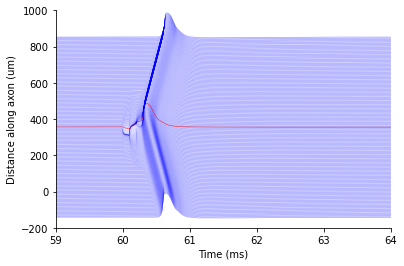

In [25]:
# Sanity check to see if im recording a spike
vInit = -70
numSeg = axon.nseg
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
offset = Stim['vInit']
for cnt in range(numSeg):
    if cnt==numSeg/2:
        plt.plot(t,np.array(vRecord[cnt])+offset,'r',linewidth=0.5)
    else:
        plt.plot(t,np.array(vRecord[cnt])+offset,'b',linewidth=0.1)
    offset += 2
plt.xlim(Stim['initDur']+9,Stim['initDur']+14)
plt.ylim(-200,1000)
plt.xlabel('Time (ms)')
plt.ylabel('Distance along axon (um)')

## Next, let's plot spike initation along the fiber 

In [213]:
t = np.array(t)

In [214]:
## Find index in vRecord of spike initiation

# First, truncate out first 50 time samples (initDur)
vRecord_trunc = vRecord[:,int(Stim['initDur']/Stim['initDt']):]
t_trunc = t[int(Stim['initDur']/Stim['initDt']):]
# Second, truncate initial delay period (delay)
vRecord_trunc = vRecord_trunc[:,int((Stim['delay']+0.15)/Stim['dt']):]
t_trunc = t_trunc[int((Stim['delay']+0.15)/Stim['dt']):]

In [215]:
print(vRecord_trunc.shape)
print(t_trunc.shape)

(500, 7971)
(7971,)


Text(0, 0.5, 'Distance along axon (um)')

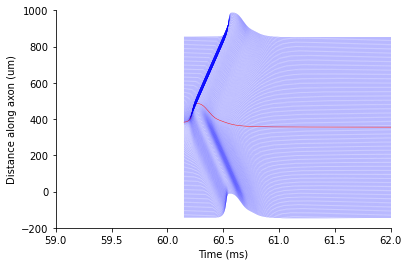

In [247]:
# Check spike output 
vInit = -70
numSeg = axon.nseg
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
offset = Stim['vInit']
for cnt in range(numSeg):
    if cnt==numSeg/2:
        plt.plot(t_trunc,np.array(vRecord_trunc[cnt])+offset,'r',linewidth=0.5)
    else:
        plt.plot(t_trunc,np.array(vRecord_trunc[cnt])+offset,'b',linewidth=0.1)
    offset += 2
# plt.xlim(Stim['initDur']+9,Stim['initDur']+14)
plt.xlim(59,62)
plt.ylim(-200,1000)
plt.xlabel('Time (ms)')
plt.ylabel('Distance along axon (um)')

In [248]:
# find x and y index of first vRecord_trunc > 0
x,y = np.where(vRecord_trunc > 0)
print(x,y)
print(x[np.argmin(y)],y[np.argmin(y)])
print(t_trunc[y[np.argmin(y)]])

[  0   0   0 ... 499 499 499] [ 75  76  77 ... 107 108 109]
230 14
60.219999999990705


In [243]:
print(vRecord_trunc[230][14])

0.2531952880916928


In [251]:
print(t_trunc)

[ 60.15   60.155  60.16  ...  99.99   99.995 100.   ]


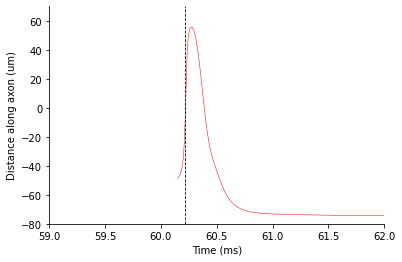

In [255]:
vInit = -70
numSeg = axon.nseg
fig = plt.figure()
ax = fig.add_subplot(111)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
offset = Stim['vInit']
cnt=230
plt.plot(t_trunc,np.array(vRecord_trunc[cnt]),'r',linewidth=0.5)

# plt.xlim(Stim['initDur']+9,Stim['initDur']+14)
plt.xlim(59,62)
plt.ylim(-80,70)
plt.xlabel('Time (ms)')
plt.ylabel('Distance along axon (um)')
plt.axvline(60.15+0.07,color='k',linestyle='--',linewidth=0.8)

## Let's plot the Rx profiles along the cell

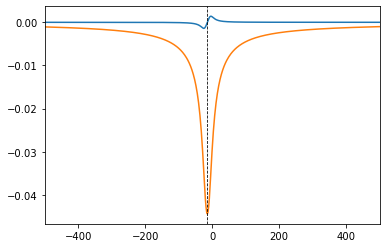

In [267]:
x_loc = []
rx = []
for seg in axon:
    x_loc.append(seg.xtra.x)
    rx.append(seg.xtra.rx)

# Calculate first numerical derivative of rx along x_loc
rx = np.array(rx)
x_loc = np.array(x_loc)
rx_grad = np.gradient(rx,x_loc)

# Plot rx and rx_grad
plt.figure()
plt.plot(x_loc,rx_grad)
plt.plot(x_loc,rx)
plt.xlim(-500,500)
plt.axvline(-15,color='k',linestyle='--',linewidth=0.8)


# plt.plot(x_loc,rx)
# plt.xlim(-200,200)
# plt.axvline(-15,color='k',linestyle='--',linewidth=0.8)


# SCRAP BELOW -----

### Attempt to plot script version, loading pickle data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle

In [ ]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

### Load data

In [ ]:
Stim['electrodes'] = [[15,5,10],[-15,5,10]]
currents = np.linspace(0,-0.37,40)

primary = []
secondary = []

for primary_elec_curr in currents:
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/'+\
                    str(primary_elec_curr)+'uA_'+\
                    str(Stim['electrodes'][0][0])+'_'+\
                    str(Stim['electrodes'][0][1])+'_'+\
                    str(Stim['electrodes'][0][2])+'.pkl'
    data = decompress_pickle(filename)
    primary.append(data[0])
    secondary.append(data[1])

In [ ]:
plt.scatter(primary,secondary)
plt.xlabel('Primary electrode current (uA)')
plt.ylabel('Secondary electrode current (uA)')
plt.xlim(-0.4,0.1)
plt.ylim(-0.4,0.1)

In [ ]:
Stim['electrodes'] = [[15,5,70],[-15,5,70]]
# currents = np.linspace(0,-0.2,40)
# currents = np.linspace(0,-0.3,40)
# currents = np.linspace(0,-0.7,40)
# currents = np.linspace(0,-1.5,100)
currents = np.linspace(0,-4,100)

primary_all = []
secondary_all = []

for primary_elec_curr in currents:
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites_'+\
                    str(primary_elec_curr)+'uA_'+\
                    str(Stim['electrodes'][0][0])+'_'+\
                    str(Stim['electrodes'][0][1])+'_'+\
                    str(Stim['electrodes'][0][2])+'.pkl'
    data = decompress_pickle(filename)
    primary_all.append(data[0])
    secondary_all.append(data[1])

In [ ]:
# Function to find data for a given electrode position
import os 

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds


In [ ]:
currents,thresholds = findData([15,5,70],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/')

electrodes = [[15,5,70],[15,5,70]]

### Function takes in electrode postion and returns multisite data

In [ ]:
primary_10,secondary_10 = findData([15,5,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')

primary_20,secondary_20 = findData([15,5,20],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_70,secondary_70 = findData([15,5,70],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_50,secondary_50 = findData([15,5,50],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_60,secondary_60 = findData([15,5,60],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_30,secondary_30 = findData([15,5,30],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')

In [ ]:
primary_0,secondary_0 = findData([15,0,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_5,secondary_5 = findData([15,5,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_10,secondary_10 = findData([15,10,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_20,secondary_20 = findData([15,20,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_30,secondary_30 = findData([15,30,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')
primary_60,secondary_60 = findData([15,60,10],'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites/')


In [ ]:
plt.scatter(np.abs(primary_0),np.abs(secondary_0))
plt.scatter(np.abs(primary_5),np.abs(secondary_5))
plt.scatter(np.abs(primary_10),np.abs(secondary_10))
plt.scatter(np.abs(primary_20),np.abs(secondary_20))
plt.scatter(np.abs(primary_30),np.abs(secondary_30))
plt.scatter(np.abs(primary_60),np.abs(secondary_60))





plt.xlabel('Primary electrode current (uA)')
plt.ylabel('Secondary electrode current (uA)')
plt.xlim(-0.1,5)
plt.ylim(-0.1,5)
plt.legend(['0um','5um','10um','20um','30um','60um'])

In [ ]:
plt.scatter(np.abs(primary_10),np.abs(secondary_10))

plt.scatter(np.abs(primary_20),np.abs(secondary_20))

plt.scatter(np.abs(primary_30),np.abs(secondary_30))
plt.scatter(np.abs(primary_50),np.abs(secondary_50))
plt.scatter(np.abs(primary_60),np.abs(secondary_60))
plt.scatter(np.abs(primary_70),np.abs(secondary_70))

plt.xlabel('Primary electrode current (uA)')
plt.ylabel('Secondary electrode current (uA)')
plt.xlim(-0.1,1.5)
plt.ylim(-0.1,1.5)
plt.legend(['10um','20um','30um','50um','60um','70um'])

In [ ]:
plt.scatter(np.abs(primary),np.abs(secondary))
plt.scatter(np.abs(primary_all),np.abs(secondary_all))
plt.xlabel('Primary electrode current (uA)')
plt.ylabel('Secondary electrode current (uA)')
plt.xlim(-0.05,0.4)
plt.ylim(-0.05,0.4)
plt.legend(['Single site','All sites'])

In [ ]:
Stim['electrodes'] = [[15,5,10],[-15,5,10]]
currents = np.linspace(0,-0.37,40)

primary_all = []
secondary_all = []

for primary_elec_curr in currents:
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites_'+\
                    str(primary_elec_curr)+'uA_'+\
                    str(Stim['electrodes'][0][0])+'_'+\
                    str(Stim['electrodes'][0][1])+'_'+\
                    str(Stim['electrodes'][0][2])+'.pkl'
    data = decompress_pickle(filename)
    primary_all.append(data[0])
    secondary_all.append(data[1])

In [ ]:
plt.scatter(np.abs(primary),np.abs(secondary))
plt.scatter(np.abs(primary_all),np.abs(secondary_all))
plt.xlabel('Primary electrode current (uA)')
plt.ylabel('Secondary electrode current (uA)')
plt.xlim(-0.05,0.4)
plt.ylim(-0.05,0.4)
plt.legend(['Single site','All sites'])

### Seperate out electrodes further (60um spacing)

In [ ]:
Stim['electrodes'] = [[30,5,10],[-30,5,10]]
currents = np.linspace(0,-0.7,40)

primary = []
secondary = []

for primary_elec_curr in currents:
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/'+\
                    str(primary_elec_curr)+'uA_'+\
                    str(Stim['electrodes'][0][0])+'_'+\
                    str(Stim['electrodes'][0][1])+'_'+\
                    str(Stim['electrodes'][0][2])+'.pkl'
    data = decompress_pickle(filename)
    primary.append(data[0])
    secondary.append(data[1])

In [ ]:
Stim['electrodes'] = [[30,5,10],[-30,5,10]]
currents = np.linspace(0,-0.7,40)

primary_all = []
secondary_all = []

for primary_elec_curr in currents:
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/10um/allSites_'+\
                    str(primary_elec_curr)+'uA_'+\
                    str(Stim['electrodes'][0][0])+'_'+\
                    str(Stim['electrodes'][0][1])+'_'+\
                    str(Stim['electrodes'][0][2])+'.pkl'
    data = decompress_pickle(filename)
    primary_all.append(data[0])
    secondary_all.append(data[1])

In [ ]:
plt.scatter(np.abs(primary),np.abs(secondary))
plt.scatter(np.abs(primary_all),np.abs(secondary_all))
plt.xlabel('Primary electrode current (uA)')
plt.ylabel('Secondary electrode current (uA)')
plt.xlim(-0.05,0.8)
plt.ylim(-0.05,0.8)
plt.legend(['Single site','All sites'])

In [41]:
# Double for loop for all combinations of current in (i1,i2) for i1 and i2 ranging from 0 to 4uA, 0.1uA increments
currents = np.arange(0,2.1,0.1)
for i1 in currents:
    for i2 in currents:
        print(round(i1,1),round(i2,1))


0.0 0.0
0.0 0.1
0.0 0.2
0.0 0.3
0.0 0.4
0.0 0.5
0.0 0.6
0.0 0.7
0.0 0.8
0.0 0.9
0.0 1.0
0.0 1.1
0.0 1.2
0.0 1.3
0.0 1.4
0.0 1.5
0.0 1.6
0.0 1.7
0.0 1.8
0.0 1.9
0.0 2.0
0.1 0.0
0.1 0.1
0.1 0.2
0.1 0.3
0.1 0.4
0.1 0.5
0.1 0.6
0.1 0.7
0.1 0.8
0.1 0.9
0.1 1.0
0.1 1.1
0.1 1.2
0.1 1.3
0.1 1.4
0.1 1.5
0.1 1.6
0.1 1.7
0.1 1.8
0.1 1.9
0.1 2.0
0.2 0.0
0.2 0.1
0.2 0.2
0.2 0.3
0.2 0.4
0.2 0.5
0.2 0.6
0.2 0.7
0.2 0.8
0.2 0.9
0.2 1.0
0.2 1.1
0.2 1.2
0.2 1.3
0.2 1.4
0.2 1.5
0.2 1.6
0.2 1.7
0.2 1.8
0.2 1.9
0.2 2.0
0.3 0.0
0.3 0.1
0.3 0.2
0.3 0.3
0.3 0.4
0.3 0.5
0.3 0.6
0.3 0.7
0.3 0.8
0.3 0.9
0.3 1.0
0.3 1.1
0.3 1.2
0.3 1.3
0.3 1.4
0.3 1.5
0.3 1.6
0.3 1.7
0.3 1.8
0.3 1.9
0.3 2.0
0.4 0.0
0.4 0.1
0.4 0.2
0.4 0.3
0.4 0.4
0.4 0.5
0.4 0.6
0.4 0.7
0.4 0.8
0.4 0.9
0.4 1.0
0.4 1.1
0.4 1.2
0.4 1.3
0.4 1.4
0.4 1.5
0.4 1.6
0.4 1.7
0.4 1.8
0.4 1.9
0.4 2.0
0.5 0.0
0.5 0.1
0.5 0.2
0.5 0.3
0.5 0.4
0.5 0.5
0.5 0.6
0.5 0.7
0.5 0.8
0.5 0.9
0.5 1.0
0.5 1.1
0.5 1.2
0.5 1.3
0.5 1.4
0.5 1.5
0.5 1.6
0.5 1.7
0.5 1.8
0.5 1.9
